/home/mad/anaconda3/envs/rbx2025/lib/python3.13/site-packages/rebound/simulation.py:259: RuntimeWarning: Spin axes are not being evolved. Call rebx_spin_initialize_ode to evolve

  warnings.warn(msg[1:], RuntimeWarning)


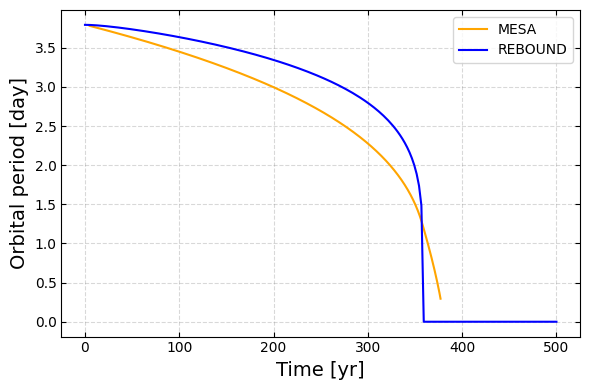

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rebound
import reboundx

# -----------------------
# Model parameters
# -----------------------
AU_PER_RSUN = 1.0 / 215.032
DAYS_PER_YEAR = 365.0

# Binary properties
M1 = 1.0
M2 = 1.0
A0_AU = 0.06
R_STAR_AU = AU_PER_RSUN  # 1 Rsun in AU

# Tidal / spin parameters
K2 = 0.07
TAU_YR = 0.1 / 365.0
K2_MOI = 0.25

# Magnetic braking parameters
TAU_CONV_YR = 12.5 / 365.25
MB_ROSSBY_SAT = 0.1
MB_K = 1.0e55  # intentionally large for a strong demo effect

# Integration / comparison data
T_END_YR = 500.0
N_SAMPLES = 200
MESA_BINARY_FILE = "./mesa/binary_history.dataMB"


def build_simulation():
    """Create a circular equal-mass binary with tides and magnetic braking."""
    sim = rebound.Simulation()
    sim.units = ("AU", "yr", "Msun")
    sim.integrator = "whfast"

    total_mass = M1 + M2
    orbital_speed = np.sqrt(sim.G * total_mass / A0_AU)

    # Place the two stars in a circular orbit in the center-of-mass frame.
    sim.add(
        m=M1,
        r=R_STAR_AU,
        x=-A0_AU * M2 / total_mass,
        vy=-orbital_speed * M2 / total_mass,
    )
    sim.add(
        m=M2,
        r=R_STAR_AU,
        x=+A0_AU * M1 / total_mass,
        vy=+orbital_speed * M1 / total_mass,
    )
    sim.move_to_com()

    primary = sim.particles[0]
    secondary = sim.particles[1]
    orbit = secondary.orbit(primary=primary)

    # Resolve the orbit with a modest timestep.
    sim.dt = orbit.P / 10.0

    # Attach REBOUNDx and keep the Extras object alive.
    rebx = reboundx.Extras(sim)

    # Start both stars synchronized with the orbit.
    omega_sync = 2.0 * np.pi / orbit.P
    for p in (primary, secondary):
        p.params["Omega"] = np.array([0.0, 0.0, omega_sync])
        p.params["I"] = K2_MOI * p.m * R_STAR_AU**2
        p.params["k2"] = K2
        p.params["tau"] = TAU_YR
        p.r = R_STAR_AU

    # Enable magnetic braking on both stars.
    mb = rebx.load_operator("magnetic_braking")
    rebx.add_operator(mb)
    mb.params["mb_Msun"] = 1.0
    mb.params["mb_Rsun"] = AU_PER_RSUN
    mb.params["mb_year"] = 1.0
    mb.params["mb_Rossby_sat"] = MB_ROSSBY_SAT
    mb.params["mb_K"] = MB_K

    for p in (primary, secondary):
        p.params["mb_on"] = 1
        p.params["mb_convective"] = 1
        p.params["mb_tau_conv"] = TAU_CONV_YR

    # Add equilibrium tides with spin evolution.
    rebx.add_force(rebx.load_force("tides_spin"))

    return sim, rebx


def orbital_period_days(sim):
    """Return the instantaneous binary orbital period in days."""
    primary = sim.particles[0]
    secondary = sim.particles[1]
    orbit = secondary.orbit(primary=primary)
    return orbit.P * DAYS_PER_YEAR


# Build the simulation.
# Keep rebx referenced so the REBOUNDx operators/forces remain attached.
sim, rebx = build_simulation()

# Integrate and store the orbital period history.
times = np.linspace(0.0, T_END_YR, N_SAMPLES)
time_history = []
period_days_history = []

for t in times:
    sim.integrate(t)

    if sim.N < 2:
        break

    time_history.append(sim.t)
    period_days_history.append(orbital_period_days(sim))

time_history = np.asarray(time_history)
period_days_history = np.asarray(period_days_history)

# Load the MESA comparison track.
mesa_binary = pd.read_csv(MESA_BINARY_FILE, header=0, skiprows=5, sep=r"\s+")

# Plot orbital period evolution.
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(mesa_binary["age"], mesa_binary["period_days"], c="orange", label="MESA")
ax.plot(time_history, period_days_history, c="blue", label="REBOUND")

ax.set_xlabel("Time [yr]", fontsize=14)
ax.set_ylabel("Orbital period [day]", fontsize=14)
ax.tick_params(direction="in", top=True, right=True)
ax.legend(loc=0)
ax.grid(True, alpha=0.3, ls="--", c="grey")

fig.tight_layout()
plt.show()